# CLV Monetary Conversion and Tier Segmentation

## Objective

Convert predicted future purchase frequency into monetary Customer Lifetime Value (CLV) in EUR for Decathlon Spain members, then segment customers into actionable value tiers.

**Pipeline Flow**:
1. Compute global Average Order Value (AOV) per snapshot date
2. Convert predicted frequency to 12-month GMV: `pred_gmv_12m = pred_freq_12m × AOV_global_12m`
3. Extrapolate to 3-year CLV: `pred_clv_3y = 3 × pred_gmv_12m`
4. Segment customers into 5 tiers (4 core value tiers + inactive segment) for prioritization

## Key Tables

* **Input**: `dev_datalake_insight_analytics_spain.clv_freq_predictions_v5`
* **Output**: `dev_datalake_insight_analytics_spain.clv_monetary_predictions_v5_global`
* **Segmented Output**: `dev_datalake_insight_analytics_spain.clv_forecast_latest_v5_segmented`

## Validation Period Context

This pipeline operates on the out-of-sample validation period (second half of 2024) used in model evaluation. The monetary conversion and tier segmentation are applied to this validation window to maintain consistency with the project's predictive evaluation framework, ensuring that all CLV metrics reflect the model's performance on held-out data.

## Anti-Leakage Guarantee

All AOV computations use only transactions where `txn_date ≤ snapshot_date` with a 365-day lookback window to prevent data leakage.

## Global AOV Computation

Compute a single Average Order Value (AOV) for each snapshot date using all Spain transactions from the past 365 days.

**Formula**: `AOV = Total Gross GMV / Number of Sale Transactions`

**Anti-Leakage**: Only transactions where `DATE(gmv_recorded_at) ≤ snapshot_date` are included.

**Data Source**: `datalake_gold.sales.sales_detail` joined with `datalake_silver.member_purchase.f_member_purchase`

**Rationale**: Global AOV provides a stable and interpretable baseline to convert predicted purchase frequency into monetary value. This approach does not attempt to model future basket value at the individual customer level, but rather creates a practical monetary CLV layer on top of the frequency predictions.

### Data Source Selection

**Primary Table**: `datalake_gold.sales.sales_detail`

**Rationale**:
* Comprehensive transactional data with sale, return, and cancel operations
* Contains required fields: `gmv_recorded_at`, `gmv_amount`, `item_operation_type`, `economical_businessunit_country_code`, `transaction_id`
* Can be joined to `f_member_purchase` via `transaction_id` for member linkage
* Gold layer with validated, cleaned data
* Partitioned by year for efficient queries

In [0]:
# First, identify all snapshot dates in the predictions table
print("=== SNAPSHOT DATES IN PREDICTIONS ===")

try:
    snapshot_dates = spark.sql("""
        SELECT 
            snapshot_date,
            COUNT(DISTINCT member_id) as num_members,
            COUNT(*) as num_records
        FROM dev_datalake_insight_analytics_spain.clv_freq_predictions_v5
        GROUP BY snapshot_date
        ORDER BY snapshot_date
    """)
    
    display(snapshot_dates)
    
    # Store dates for later use
    snapshot_dates_list = [row.snapshot_date for row in snapshot_dates.collect()]
    print(f"\nFound {len(snapshot_dates_list)} snapshot dates")
    print(f"Date range: {min(snapshot_dates_list)} to {max(snapshot_dates_list)}")
    
except Exception as e:
    print(f"Error: {e}")
    print("\nWill define snapshot dates manually based on typical training windows...")
    # Fallback: define common snapshot dates
    snapshot_dates_list = spark.sql("""
        SELECT DISTINCT DATE_TRUNC('month', CURRENT_DATE() - INTERVAL (seq * 30) DAY) as snapshot_date
        FROM (SELECT explode(sequence(0, 24)) as seq)
        ORDER BY snapshot_date
    """).collect()

=== SNAPSHOT DATES IN PREDICTIONS ===


snapshot_date,num_members,num_records
2024-07-31,218082,218082
2024-08-31,217630,217630
2024-09-30,217191,217191
2024-10-31,217416,217416
2024-11-30,217462,217462
2024-12-31,217665,217665



Found 6 snapshot dates
Date range: 2024-07-31 to 2024-12-31


In [0]:
# Compute Global AOV per Snapshot Date using BATCH PROCESSING
# This avoids large broadcast joins by processing one snapshot date at a time

import pandas as pd
from datetime import timedelta

print("=== GLOBAL AOV COMPUTATION (BATCH PROCESSING) ===")
print("Processing snapshot dates incrementally to avoid OOM errors\n")

# Disable broadcast joins
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

# Step 1: Get all snapshot dates that need processing
print("Step 1: Fetching snapshot dates...")
snapshot_dates = spark.sql("""
  SELECT DISTINCT snapshot_date
  FROM dev_datalake_insight_analytics_spain.clv_freq_predictions_v5
  ORDER BY snapshot_date
""").collect()

num_snapshots = len(snapshot_dates)
print(f"✓ Found {num_snapshots} snapshot dates to process")
if num_snapshots > 0:
    print(f"  Date range: {snapshot_dates[0][0]} to {snapshot_dates[-1][0]}\n")

# Step 2: Drop and recreate the output table
output_table = "dev_datalake_insight_analytics_spain.aov_global_ref_batch"
print(f"Step 2: Preparing output table: {output_table}")

spark.sql(f"DROP TABLE IF EXISTS {output_table}")
print("✓ Output table cleared\n")

# Step 3: Process each snapshot date individually
print(f"Step 3: Processing {num_snapshots} snapshots...")

for idx, row in enumerate(snapshot_dates, 1):
    snapshot_date = row[0]
    
    # Calculate lookback window for this snapshot (365 days)
    lookback_start = snapshot_date - timedelta(days=365)
    
    # Compute AOV for this single snapshot date
    # Key optimization: filter both tables early to minimize data volume
    batch_aov = spark.sql(f"""
    WITH 
    -- Get member transaction IDs (full table, but small extraction)
    member_txn_ids AS (
      SELECT DISTINCT transaction_id
      FROM datalake_silver.member_purchase.f_member_purchase
    ),
    
    -- Filter sales for Spain and relevant date range FIRST, then aggregate
    tx_sales_filtered AS (
      SELECT 
        sales.transaction_id,
        DATE(sales.gmv_recorded_at) as txn_date,
        SUM(CASE WHEN sales.item_operation_type = 'sale' THEN ABS(sales.gmv_amount) ELSE 0 END) as gross_gmv_sales_txn
      FROM datalake_gold.sales.sales_detail sales
      WHERE sales.economical_businessunit_country_code = 'ES'
        AND sales.item_operation_type IN ('sale', 'return', 'cancel')
        AND DATE(sales.gmv_recorded_at) > DATE('{lookback_start.strftime('%Y-%m-%d')}')
        AND DATE(sales.gmv_recorded_at) <= DATE('{snapshot_date.strftime('%Y-%m-%d')}')
      GROUP BY sales.transaction_id, DATE(sales.gmv_recorded_at)
    ),
    
    -- Join filtered sales with member IDs (both are now small)
    tx_sales_members AS (
      SELECT 
        ts.transaction_id,
        ts.txn_date,
        ts.gross_gmv_sales_txn
      FROM tx_sales_filtered ts
      INNER JOIN member_txn_ids mt
        ON ts.transaction_id = mt.transaction_id
    ),
    
    -- Aggregate to compute AOV for this snapshot
    aov_metrics AS (
      SELECT 
        SUM(gross_gmv_sales_txn) as total_gross_gmv_sales,
        COUNT(DISTINCT CASE WHEN gross_gmv_sales_txn > 0 THEN transaction_id END) as num_sale_transactions
      FROM tx_sales_members
    )
    
    SELECT 
      DATE('{snapshot_date.strftime('%Y-%m-%d')}') as snapshot_date,
      total_gross_gmv_sales,
      num_sale_transactions,
      
      CASE 
        WHEN num_sale_transactions > 0 
        THEN ROUND(total_gross_gmv_sales / num_sale_transactions, 2)
        ELSE 0.0
      END as aov_global_12m,
      
      CASE 
        WHEN num_sale_transactions > 0 THEN
          LEAST(
            ROUND(total_gross_gmv_sales / num_sale_transactions, 2),
            (
              SELECT percentile_approx(gross_gmv_sales_txn, 0.99) 
              FROM tx_sales_members
            )
          )
        ELSE 0.0
      END as aov_global_12m_winsorized
      
    FROM aov_metrics
    """)
    
    # Write batch result to Delta table (append mode)
    if idx == 1:
        # First batch: create table
        batch_aov.write.mode("overwrite").format("delta").saveAsTable(output_table)
    else:
        # Subsequent batches: append
        batch_aov.write.mode("append").format("delta").saveAsTable(output_table)
    
    # Print progress milestones only
    if idx == 1 or idx == num_snapshots or idx % 3 == 0:
        print(f"  ✓ Processed {idx}/{num_snapshots} snapshots")

print(f"✓ Batch processing complete: {num_snapshots} snapshots processed\n")

# Step 4: Create view pointing to materialized table for compatibility
print("Step 4: Creating aov_global_ref view...")
spark.sql("""
  CREATE OR REPLACE TEMPORARY VIEW aov_global_ref AS
  SELECT * FROM dev_datalake_insight_analytics_spain.aov_global_ref_batch
  ORDER BY snapshot_date
""")
print("✓ View created\n")

# Step 5: Verify results
print("Step 5: Verifying results...")
result_count = spark.sql(f"SELECT COUNT(*) as cnt FROM {output_table}").collect()[0][0]
print(f"✓ Final table contains {result_count} snapshot dates\n")

print("=" * 70)
print("GLOBAL AOV COMPUTATION COMPLETE")
print("=" * 70)
print(f"\nOutput table: {output_table}")
print("View: aov_global_ref (ready for downstream processing)")

=== GLOBAL AOV COMPUTATION (BATCH PROCESSING) ===
Processing snapshot dates incrementally to avoid OOM errors

Step 1: Fetching snapshot dates...
✓ Found 6 snapshot dates to process
  Date range: 2024-07-31 to 2024-12-31

Step 2: Preparing output table: dev_datalake_insight_analytics_spain.aov_global_ref_batch
✓ Output table cleared

Step 3: Processing 6 snapshots (batch size: 1)...
----------------------------------------------------------------------
[1/6] Processing 2024-07-31 (lookback: 2023-08-01 to 2024-07-31)
[2/6] Processing 2024-08-31 (lookback: 2023-09-01 to 2024-08-31)
[3/6] Processing 2024-09-30 (lookback: 2023-10-01 to 2024-09-30)
[4/6] Processing 2024-10-31 (lookback: 2023-11-01 to 2024-10-31)
[5/6] Processing 2024-11-30 (lookback: 2023-12-01 to 2024-11-30)
  ✓ Processed 5/6 snapshots
[6/6] Processing 2024-12-31 (lookback: 2024-01-01 to 2024-12-31)
  ✓ Processed 6/6 snapshots
----------------------------------------------------------------------

✓ Batch processing comple

In [0]:
# Validate the global AOV computation results
# Reading from materialized Delta table (no recomputation)

print("=== GLOBAL AOV VALIDATION ===")
print("Reading from materialized Delta table...\n")

# Read from the materialized table
aov_global = spark.sql("SELECT * FROM aov_global_ref ORDER BY snapshot_date")

print("Global AOV by Snapshot Date:")
display(aov_global)

print("\nSummary Statistics:")
aov_summary = spark.sql("""
    SELECT 
        COUNT(*) as num_snapshots,
        ROUND(MIN(aov_global_12m), 2) as min_aov,
        ROUND(AVG(aov_global_12m), 2) as avg_aov,
        ROUND(percentile_approx(aov_global_12m, 0.5), 2) as median_aov,
        ROUND(MAX(aov_global_12m), 2) as max_aov,
        MIN(num_sale_transactions) as min_transactions,
        MAX(num_sale_transactions) as max_transactions
    FROM aov_global_ref
""")

display(aov_summary)

print("\n✓ Validation complete - AOV table is materialized and ready for downstream processing")

=== GLOBAL AOV VALIDATION ===
Reading from materialized Delta table...

Global AOV by Snapshot Date:


snapshot_date,total_gross_gmv_sales,num_sale_transactions,aov_global_12m,aov_global_12m_winsorized
2024-07-31,1442934190.68,29641217,48.68,48.68
2024-08-31,1458756319.28,29995101,48.63,48.63
2024-09-30,1471679590.48,30206861,48.72,48.72
2024-10-31,1477523422.99,30288288,48.78,48.78
2024-11-30,1477138932.68,30151648,48.99,48.99
2024-12-31,1494249205.61,30359554,49.22,49.22



Summary Statistics:


num_snapshots,min_aov,avg_aov,median_aov,max_aov,min_transactions,max_transactions
6,48.63,48.84,48.72,49.22,29641217,30359554



✓ Validation complete - AOV table is materialized and ready for downstream processing


## Monetary CLV Conversion

Convert predicted purchase frequency into monetary 3-year Customer Lifetime Value using the global AOV computed above.

**Conversion Logic**:
1. **12-Month GMV**: `pred_gmv_12m = pred_freq_12m × aov_global_12m`
2. **3-Year CLV**: `pred_clv_3y = 3 × pred_gmv_12m`

**Output Table**: `dev_datalake_insight_analytics_spain.clv_monetary_predictions_v5_global`

**3-Year Horizon Rationale**: The predictive model estimates purchase frequency over a 12-month horizon. This is then extrapolated to a 3-year CLV measure to align with Decathlon's business objective of evaluating customer value over a 3-year planning horizon, as defined in the capstone project scope.

In [0]:
%sql
-- Create the final output table with monetary CLV predictions
-- Converts predicted frequency to 12-month GMV and 3-year CLV using global AOV

CREATE OR REPLACE TABLE dev_datalake_insight_analytics_spain.clv_monetary_predictions_v5_global
USING DELTA
COMMENT 'CLV monetary conversion: Predicted frequency converted to GMV and 3-year CLV in EUR using global AOV'
AS
WITH 
predictions_base AS (
  SELECT 
    member_id,
    snapshot_date,
    y_true,  -- Actual future frequency if available
    y_pred_gbt_enhanced,
    -- Clamp predicted frequency to non-negative
    GREATEST(0.0, y_pred_gbt_enhanced) as pred_freq_12m
  FROM dev_datalake_insight_analytics_spain.clv_freq_predictions_v5
),

-- Join predictions with global AOV
predictions_with_aov AS (
  SELECT 
    p.member_id,
    p.snapshot_date,
    p.y_true,
    p.pred_freq_12m,
    
    -- Global AOV and derived metrics
    aov_g.aov_global_12m,
    p.pred_freq_12m * aov_g.aov_global_12m as pred_gmv_12m_global,
    3.0 * p.pred_freq_12m * aov_g.aov_global_12m as pred_clv_3y_global
    
  FROM predictions_base p
  
  -- Join global AOV (required)
  INNER JOIN aov_global_ref aov_g
    ON p.snapshot_date = aov_g.snapshot_date
)

SELECT 
  member_id,
  snapshot_date,
  y_true,
  pred_freq_12m,
  aov_global_12m,
  pred_gmv_12m_global,
  pred_clv_3y_global
FROM predictions_with_aov

num_affected_rows,num_inserted_rows


In [0]:
# Verify the output table was created successfully
print("=== OUTPUT TABLE CREATION VERIFICATION ===")

try:
    # Check table exists and get row count
    table_info = spark.sql("""
        SELECT 
            COUNT(*) as total_rows,
            COUNT(DISTINCT member_id) as unique_members,
            COUNT(DISTINCT snapshot_date) as unique_snapshots
        FROM dev_datalake_insight_analytics_spain.clv_monetary_predictions_v5_global
    """)
    
    print("\nTable created successfully")
    print("\nTable Statistics:")
    display(table_info)
    
except Exception as e:
    print(f"Error: {e}")

=== OUTPUT TABLE CREATION VERIFICATION ===

Table created successfully

Table Statistics:


total_rows,unique_members,unique_snapshots
1305446,1241483,6


In [0]:
# Analyze CLV distribution to verify reasonable predictions
print("=== CLV DISTRIBUTION CHECK ===")

clv_distribution = spark.sql("""
    SELECT 
        COUNT(*) as total_members,
        ROUND(AVG(pred_clv_3y_global), 2) as avg_clv,
        ROUND(percentile_approx(pred_clv_3y_global, 0.25), 2) as p25_clv,
        ROUND(percentile_approx(pred_clv_3y_global, 0.50), 2) as median_clv,
        ROUND(percentile_approx(pred_clv_3y_global, 0.75), 2) as p75_clv,
        ROUND(percentile_approx(pred_clv_3y_global, 0.90), 2) as p90_clv,
        ROUND(percentile_approx(pred_clv_3y_global, 0.95), 2) as p95_clv,
        ROUND(MIN(pred_clv_3y_global), 2) as min_clv,
        ROUND(MAX(pred_clv_3y_global), 2) as max_clv
    FROM dev_datalake_insight_analytics_spain.clv_monetary_predictions_v5_global
""")

print("\nCLV Distribution (EUR):")
display(clv_distribution)

=== CLV DISTRIBUTION CHECK ===

CLV Distribution (EUR):


total_members,avg_clv,p25_clv,median_clv,p75_clv,p90_clv,p95_clv,min_clv,max_clv
1305446,373.91,122.69,222.62,464.42,833.48,1186.81,25.48,9077.76


## Customer Tier Segmentation

Segment customers into 5 tiers based on predicted 3-year CLV: 4 core value tiers (Platinum, Gold, Silver, Bronze) for active customers, plus an Inactive segment for customers with minimal predicted engagement.

### Tier Definitions

| Tier | CLV Range (EUR) | Description |
|------|----------------|-------------|
| **Platinum** | ≥ 1,000 | Highest value customers - VIP treatment |
| **Gold** | 500 - 999 | High value customers - retention focus |
| **Silver** | 200 - 499 | Medium value customers - growth opportunity |
| **Bronze** | 50 - 199 | Active customers - engagement campaigns |
| **Inactive** | < 50 | Low engagement - reactivation campaigns |

### Implementation

The segmentation logic is applied to the latest snapshot predictions, creating an actionable customer segmentation table with:
* CLV tier labels
* Tier ordering for sorting
* Percentile rankings
* Value driver indicators (frequency vs. AOV dominated)

In [0]:
%sql
-- Extract latest snapshot predictions for tier segmentation
-- Tier segmentation is applied to the most recent snapshot date only

CREATE OR REPLACE TABLE dev_datalake_insight_analytics_spain.clv_forecast_latest_v5
USING DELTA
COMMENT 'CLV predictions using latest snapshot date - input for tier segmentation'
AS
WITH latest_snapshot AS (
  SELECT MAX(snapshot_date) as max_snapshot_date
  FROM dev_datalake_insight_analytics_spain.clv_monetary_predictions_v5_global
)
SELECT 
  mp.*
FROM dev_datalake_insight_analytics_spain.clv_monetary_predictions_v5_global mp
INNER JOIN latest_snapshot ls
  ON mp.snapshot_date = ls.max_snapshot_date

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Create customer segmentation table with CLV tiers and value driver classification
-- Applies tier segmentation logic to latest snapshot predictions

CREATE OR REPLACE TABLE dev_datalake_insight_analytics_spain.clv_forecast_latest_v5_segmented
USING DELTA
COMMENT 'CLV forecast with 4-tier customer segmentation and value driver analysis'
AS
WITH base_forecast AS (
  SELECT *
  FROM dev_datalake_insight_analytics_spain.clv_forecast_latest_v5
),

-- Calculate percentile ranks
percentile_ranks AS (
  SELECT 
    *,
    PERCENT_RANK() OVER (ORDER BY pred_clv_3y_global DESC) as clv_percentile_rank
  FROM base_forecast
),

-- Apply tier segmentation logic
segmented_forecast AS (
  SELECT 
    *,
    
    -- CLV Tier Segmentation (4 tiers based on 3-year CLV thresholds)
    CASE 
      WHEN pred_clv_3y_global >= 1000 THEN 'Platinum'
      WHEN pred_clv_3y_global >= 500 THEN 'Gold'
      WHEN pred_clv_3y_global >= 200 THEN 'Silver'
      WHEN pred_clv_3y_global >= 50 THEN 'Bronze'
      ELSE 'Inactive'
    END as clv_tier,
    
    -- Tier order for sorting
    CASE 
      WHEN pred_clv_3y_global >= 1000 THEN 1
      WHEN pred_clv_3y_global >= 500 THEN 2
      WHEN pred_clv_3y_global >= 200 THEN 3
      WHEN pred_clv_3y_global >= 50 THEN 4
      ELSE 5
    END as clv_tier_order,
    
    -- Percentile-based segments
    CASE 
      WHEN clv_percentile_rank <= 0.01 THEN 'Top 1%'
      WHEN clv_percentile_rank <= 0.05 THEN 'Top 5%'
      WHEN clv_percentile_rank <= 0.10 THEN 'Top 10%'
      WHEN clv_percentile_rank <= 0.25 THEN 'Top 25%'
      WHEN clv_percentile_rank <= 0.50 THEN 'Top 50%'
      ELSE 'Bottom 50%'
    END as clv_percentile_segment,
    
    -- Frequency-based segments
    CASE 
      WHEN pred_freq_12m >= 4 THEN 'High Frequency (4+ purchases/year)'
      WHEN pred_freq_12m >= 2 THEN 'Medium Frequency (2-4 purchases/year)'
      WHEN pred_freq_12m >= 1 THEN 'Low Frequency (1-2 purchases/year)'
      ELSE 'Dormant (<1 purchase/year)'
    END as frequency_segment,
    
    -- AOV-based segments
    CASE 
      WHEN aov_global_12m >= 100 THEN 'High AOV (EUR 100+)'
      WHEN aov_global_12m >= 60 THEN 'Medium AOV (EUR 60-100)'
      WHEN aov_global_12m >= 30 THEN 'Low AOV (EUR 30-60)'
      ELSE 'Very Low AOV (<EUR 30)'
    END as aov_segment,
    
    -- Value driver classification
    CASE 
      WHEN pred_freq_12m >= 4 AND aov_global_12m >= 80 THEN 'High Frequency + High AOV'
      WHEN pred_freq_12m >= 4 THEN 'Frequency Driven'
      WHEN aov_global_12m >= 80 THEN 'AOV Driven'
      WHEN pred_freq_12m >= 2 AND aov_global_12m >= 50 THEN 'Balanced'
      ELSE 'Low Engagement'
    END as value_driver
    
  FROM percentile_ranks
)

SELECT 
  member_id,
  snapshot_date,
  
  -- Predictions
  ROUND(pred_freq_12m, 2) as pred_freq_12m,
  ROUND(aov_global_12m, 2) as aov_global_12m,
  ROUND(pred_gmv_12m_global, 2) as pred_gmv_12m_global,
  ROUND(pred_clv_3y_global, 2) as pred_clv_3y_global,
  
  -- Tier Segments
  clv_tier,
  clv_tier_order,
  clv_percentile_segment,
  frequency_segment,
  aov_segment,
  value_driver,
  
  -- Actuals (if available)
  y_true
  
FROM segmented_forecast

num_affected_rows,num_inserted_rows


In [0]:
# Validate the tier segmentation results
print("=== TIER DISTRIBUTION SUMMARY ===")

# Tier distribution showing member count and CLV concentration
tier_summary = spark.sql("""
    SELECT 
        clv_tier,
        clv_tier_order,
        COUNT(*) as num_members,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as pct_members,
        ROUND(AVG(pred_clv_3y_global), 2) as avg_clv,
        ROUND(SUM(pred_clv_3y_global), 2) as total_clv,
        ROUND(100.0 * SUM(pred_clv_3y_global) / SUM(SUM(pred_clv_3y_global)) OVER (), 2) as pct_total_clv
    FROM dev_datalake_insight_analytics_spain.clv_forecast_latest_v5_segmented
    GROUP BY clv_tier, clv_tier_order
    ORDER BY clv_tier_order
""")

print("\nCustomer Tier Distribution:")
display(tier_summary)

print("\nTable created: dev_datalake_insight_analytics_spain.clv_forecast_latest_v5_segmented")

=== TIER DISTRIBUTION SUMMARY ===

Customer Tier Distribution:


clv_tier,clv_tier_order,num_members,pct_members,avg_clv,total_clv,pct_total_clv
Platinum,1,15236,7.00,1546.39,2.356079766E7,28.36
Gold,2,35384,16.26,698.91,2.473015353E7,29.77
Silver,3,73438,33.74,319.91,2.349319388E7,28.28
Bronze,4,93607,43.01,120.51,1.128088536E7,13.58



Table created: dev_datalake_insight_analytics_spain.clv_forecast_latest_v5_segmented


## Historical vs Predictive CLV Comparison

This section compares two CLV calculation approaches side by side. To ensure a like-for-like comparison, both methods use the **same global AOV** (`aov_global_12m`), so any difference in CLV reflects only the difference in predicted frequency.

| Method | Formula | Basis |
|---|---|---|
| **Historical (Baseline)** | `CLV = AOV_global × Freq_historical × 3` | Observed 12-month purchase count (backward-looking) |
| **Predictive (Behavioral)** | `CLV = AOV_global × Freq_predicted × 3` | GBT model with 9 engagement drivers (forward-looking) |

In [0]:
# Historical vs Predictive CLV: data loading and tier-level summary
from pyspark.sql import functions as F
import pandas as pd

# Historical CLV is recomputed here using aov_global_12m (the same AOV used for
# predicted CLV) so that the comparison isolates the frequency difference only.

df_clv_compare = spark.table("dev_datalake_insight_analytics_spain.clv_forecast_driver_flags_v5") \
    .filter(F.col("snapshot_date") == "2024-12-31") \
    .select(
        "member_id",
        "clv_tier",
        "freq_historical",
        "freq_predicted",
        F.col("aov_global_12m").cast("double").alias("aov_global_12m"),
        # Legacy calculation stored in the source table (uses a different AOV)
        F.col("clv_3y_historical").alias("clv_3y_historical_legacy"),
        "clv_3y_predicted",
        # Like-for-like historical CLV using the same global AOV as predicted CLV
        (F.col("aov_global_12m").cast("double") * F.col("freq_historical") * 3).alias("clv_3y_historical"),
        # Delta = Predictive minus Historical (same AOV, so purely a frequency effect)
        (F.col("clv_3y_predicted") - (F.col("aov_global_12m").cast("double") * F.col("freq_historical") * 3)).alias("clv_3y_delta")
    )

total_customers = df_clv_compare.count()
print(f"Total customers (Dec 2024 snapshot): {total_customers:,}\n")

# Verify AOV consistency across both methods
aov_check = df_clv_compare.select(
    F.round(F.avg("aov_global_12m"), 2).alias("avg_aov_used"),
    F.round(F.avg("clv_3y_historical"), 2).alias("avg_historical_clv"),
    F.round(F.avg("clv_3y_historical_legacy"), 2).alias("avg_historical_clv_legacy"),
    F.round(F.avg("clv_3y_predicted"), 2).alias("avg_predicted_clv")
).collect()[0]

print(f"AOV Consistency Check:")
print(f"  Global AOV (shared by both methods): EUR {aov_check['avg_aov_used']}")
print(f"  Avg Historical CLV (like-for-like):   EUR {aov_check['avg_historical_clv']}")
print(f"  Avg Historical CLV (legacy calc):     EUR {aov_check['avg_historical_clv_legacy']}")
print(f"  Avg Predicted CLV:                    EUR {aov_check['avg_predicted_clv']}")

# --- Tier-level summary ---
tier_comparison = df_clv_compare.groupBy("clv_tier").agg(
    F.count("*").alias("customers"),
    F.round(F.avg("freq_historical"), 2).alias("avg_freq_historical"),
    F.round(F.avg("freq_predicted"), 2).alias("avg_freq_predicted"),
    F.round(F.avg("clv_3y_historical"), 2).alias("avg_clv_historical"),
    F.round(F.avg("clv_3y_predicted"), 2).alias("avg_clv_predicted"),
    F.round(F.avg("clv_3y_delta"), 2).alias("avg_delta")
).orderBy(F.desc("avg_clv_predicted"))

print("\nHistorical vs Predictive CLV by Tier:")
display(tier_comparison)

# --- Delta statistics ---
delta_stats = df_clv_compare.select(
    F.round(F.mean("clv_3y_delta"), 2).alias("mean_delta"),
    F.round(F.expr("percentile_approx(clv_3y_delta, 0.50)"), 2).alias("median_delta"),
    F.sum(F.when(F.col("clv_3y_delta") > 0, 1).otherwise(0)).alias("positive"),
    F.sum(F.when(F.col("clv_3y_delta") < 0, 1).otherwise(0)).alias("negative"),
    F.sum(F.when(F.col("clv_3y_delta") == 0, 1).otherwise(0)).alias("zero")
).collect()[0]

print(f"\nDelta (Predictive − Historical):")
print(f"  Mean: EUR {delta_stats['mean_delta']}  |  Median: EUR {delta_stats['median_delta']}")
print(f"  Predictive > Historical: {delta_stats['positive']:,} ({delta_stats['positive']/total_customers*100:.1f}%)")
print(f"  Predictive < Historical: {delta_stats['negative']:,} ({delta_stats['negative']/total_customers*100:.1f}%)")
print(f"  No change:               {delta_stats['zero']:,} ({delta_stats['zero']/total_customers*100:.1f}%)")

print("\nBoth methods share the same AOV; the delta reflects only the frequency difference.")

Total customers (Dec 2024 snapshot): 217,665

AOV Consistency Check:
  Global AOV (shared by both methods): EUR 48.92
  Avg Historical CLV (like-for-like):   EUR 457.71
  Avg Historical CLV (legacy calc):     EUR 381.43
  Avg Predicted CLV:                    EUR 379.32

Historical vs Predictive CLV by Tier:


clv_tier,customers,avg_freq_historical,avg_freq_predicted,avg_clv_historical,avg_clv_predicted,avg_delta
Platinum,15150,15.35,10.49,2252.8,1540.13,-712.67
Gold,35197,6.56,4.75,963.21,696.96,-266.25
Silver,73516,2.34,2.17,342.98,318.96,-24.02
Bronze,93802,0.46,0.82,68.03,119.95,51.92



Delta (Predictive − Historical):
  Mean: EUR -78.4  |  Median: EUR 3.61
  Predictive > Historical: 110,459 (50.7%)
  Predictive < Historical: 107,206 (49.3%)
  No change:               0 (0.0%)

Both methods share the same AOV; the delta reflects only the frequency difference.


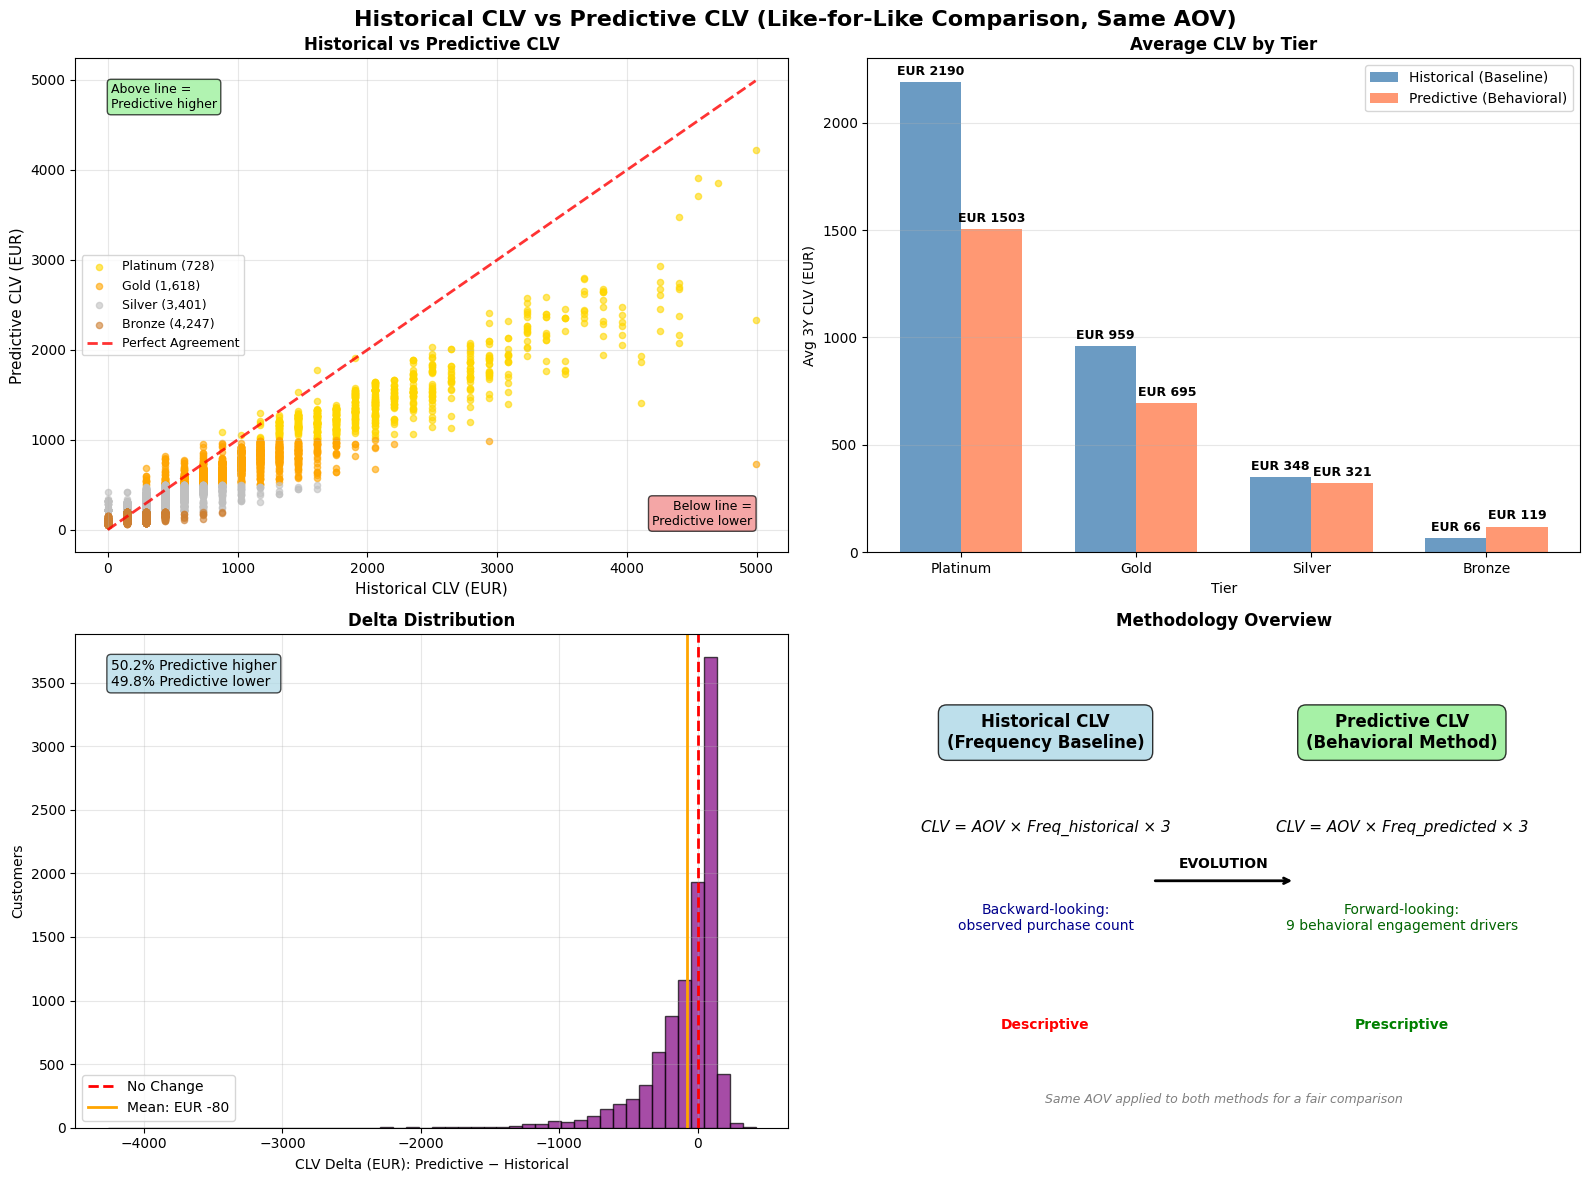


Summary: Historical mean EUR 461 vs Predictive mean EUR 382 (Delta EUR -80)
Split: 50.2% predictive higher / 49.8% predictive lower


In [0]:
# 4-panel visual comparison: Historical CLV vs Predictive CLV
import matplotlib.pyplot as plt
import numpy as np

# Sample for visualization
sample_size = 10000
df_sample = df_clv_compare.sample(fraction=min(sample_size / total_customers, 1.0), seed=42)

df_plot = df_sample.select(
    "clv_tier",
    F.col("clv_3y_historical").cast("double").alias("historical_clv"),
    F.col("clv_3y_predicted").cast("double").alias("predicted_clv"),
    F.col("clv_3y_delta").cast("double").alias("delta")
).filter(
    (F.col("clv_3y_predicted").between(0, 5000)) &
    (F.col("clv_3y_historical").between(0, 5000))
).toPandas()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Historical CLV vs Predictive CLV (Like-for-Like Comparison, Same AOV)',
             fontsize=16, fontweight='bold')

tier_colors = {'Platinum': '#FFD700', 'Gold': '#FFA500', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'}

# --- Plot 1: Scatter ---
for tier in ['Platinum', 'Gold', 'Silver', 'Bronze']:
    td = df_plot[df_plot['clv_tier'] == tier]
    if len(td) > 0:
        ax1.scatter(td['historical_clv'], td['predicted_clv'], c=tier_colors[tier],
                    alpha=0.6, s=20, label=f'{tier} ({len(td):,})')
max_val = max(df_plot['historical_clv'].max(), df_plot['predicted_clv'].max())
ax1.plot([0, max_val], [0, max_val], 'r--', alpha=0.8, lw=2, label='Perfect Agreement')
ax1.set_xlabel('Historical CLV (EUR)', fontsize=11)
ax1.set_ylabel('Predictive CLV (EUR)', fontsize=11)
ax1.set_title('Historical vs Predictive CLV', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, 'Above line =\nPredictive higher', transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax1.text(0.95, 0.05, 'Below line =\nPredictive lower', transform=ax1.transAxes, fontsize=9, va='bottom', ha='right',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# --- Plot 2: Tier bar chart ---
tier_avg = df_plot.groupby('clv_tier').agg(
    {'historical_clv': 'mean', 'predicted_clv': 'mean'}
).reindex(['Platinum', 'Gold', 'Silver', 'Bronze'])
x = range(len(tier_avg)); w = 0.35
ax2.bar([i - w/2 for i in x], tier_avg['historical_clv'], w,
        label='Historical (Baseline)', color='steelblue', alpha=0.8)
ax2.bar([i + w/2 for i in x], tier_avg['predicted_clv'], w,
        label='Predictive (Behavioral)', color='coral', alpha=0.8)
for i, (h, p) in enumerate(zip(tier_avg['historical_clv'], tier_avg['predicted_clv'])):
    ax2.text(i - w/2, h + 20, f'EUR {h:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.text(i + w/2, p + 20, f'EUR {p:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel('Tier'); ax2.set_ylabel('Avg 3Y CLV (EUR)')
ax2.set_xticks(list(x)); ax2.set_xticklabels(tier_avg.index)
ax2.set_title('Average CLV by Tier', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3, axis='y')

# --- Plot 3: Delta histogram ---
ax3.hist(df_plot['delta'], bins=50, alpha=0.7, color='purple', edgecolor='black')
ax3.axvline(0, color='red', linestyle='--', lw=2, label='No Change')
ax3.axvline(df_plot['delta'].mean(), color='orange', lw=2,
            label=f'Mean: EUR {df_plot["delta"].mean():.0f}')
pos_pct = (df_plot['delta'] > 0).mean() * 100
ax3.text(0.05, 0.95, f'{pos_pct:.1f}% Predictive higher\n{100-pos_pct:.1f}% Predictive lower',
         transform=ax3.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax3.set_xlabel('CLV Delta (EUR): Predictive \u2212 Historical'); ax3.set_ylabel('Customers')
ax3.set_title('Delta Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3)

# --- Plot 4: Methodology comparison ---
ax4.set_xticks([]); ax4.set_yticks([])
for spine in ax4.spines.values(): spine.set_visible(False)
ax4.text(0.25, 0.8, 'Historical CLV\n(Frequency Baseline)', ha='center', va='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
ax4.text(0.75, 0.8, 'Predictive CLV\n(Behavioral Method)', ha='center', va='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8))
ax4.text(0.25, 0.6, 'CLV = AOV \u00d7 Freq_historical \u00d7 3', ha='center', fontsize=11, style='italic')
ax4.text(0.75, 0.6, 'CLV = AOV \u00d7 Freq_predicted \u00d7 3', ha='center', fontsize=11, style='italic')
ax4.text(0.25, 0.4, 'Backward-looking:\nobserved purchase count', ha='center', fontsize=10, color='darkblue')
ax4.text(0.75, 0.4, 'Forward-looking:\n9 behavioral engagement drivers', ha='center', fontsize=10, color='darkgreen')
ax4.text(0.25, 0.2, 'Descriptive', ha='center', fontsize=10, color='red', fontweight='bold')
ax4.text(0.75, 0.2, 'Prescriptive', ha='center', fontsize=10, color='green', fontweight='bold')
ax4.annotate('', xy=(0.6, 0.5), xytext=(0.4, 0.5), arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax4.text(0.5, 0.52, 'EVOLUTION', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax4.text(0.5, 0.05, 'Same AOV applied to both methods for a fair comparison',
         ha='center', fontsize=9, style='italic', color='grey')
ax4.set_title('Methodology Overview', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSummary: Historical mean EUR {df_plot['historical_clv'].mean():.0f} vs Predictive mean EUR {df_plot['predicted_clv'].mean():.0f} (Delta EUR {df_plot['delta'].mean():.0f})")
print(f"Split: {pos_pct:.1f}% predictive higher / {100-pos_pct:.1f}% predictive lower")

### Interpreting the Delta Between Historical and Predictive CLV

| Customer Profile | Historical CLV | Predictive CLV | Interpretation |
|---|---|---|---|
| High historical freq + weak engagement drivers | High | Lower | Possible churn risk: high past purchases but weaker current engagement signals |
| Low historical freq + strong engagement drivers | Low | Higher | Growth opportunity: recent adoption of key behaviours may signal increased future frequency |
| High historical freq + strong engagement drivers | High | High | Core loyalists: strong engagement on both dimensions |
| Low historical freq + weak engagement drivers | Low | Low | Low engagement: limited signals on both dimensions |

**Key Takeaways**:
* **Historical CLV** assumes future behaviour mirrors past purchase frequency
* **Predictive CLV** incorporates 9 engagement drivers (app usage, omnichannel activity, fast second purchase, category diversity, etc.) to estimate future frequency
* Because both methods use the same AOV, the delta isolates the **frequency effect** only
* The near-even split (∼50/50) between positive and negative deltas shows that the behavioural model redistributes value rather than inflating it — it lifts low-frequency customers with strong engagement signals while tempering high-frequency customers with weaker signals

## Conclusion

### Pipeline Summary

This notebook implements a complete CLV monetary conversion and customer segmentation pipeline for Decathlon Spain members.

**Core Process**:
1. **Global AOV Computation**: Calculate Average Order Value per snapshot date using 365-day historical transaction data
2. **Monetary CLV Conversion**: Transform predicted purchase frequency into 12-month GMV using `pred_gmv_12m = pred_freq_12m × AOV_global_12m`
3. **3-Year CLV Projection**: Extrapolate to 3-year value using `pred_clv_3y = 3 × pred_gmv_12m`
4. **Customer Tier Segmentation**: Classify customers into 4 core value tiers (Platinum, Gold, Silver, Bronze) plus an Inactive segment
5. **Historical vs Predictive CLV Comparison**: Like-for-like comparison using the same AOV, isolating the frequency difference between the historical frequency baseline and the behavioural GBT model

### Pipeline Results

**Data Processing**:
* 6 snapshot dates (July–December 2024) | \~30M transactions per snapshot | Batch processing (1 snapshot at a time)
* Global AOV: €48.84 average (range: €48.63–€49.22) | Total runtime: \~20 minutes

**Monetary CLV Output** (`clv_monetary_predictions_v5_global`):
* 1,305,446 records | 1,241,483 unique members | Average 3Y CLV: €373.91 | Median: €222.62
* Distribution: P25=€122.69 | P75=€464.42 | P90=€833.48 | P95=€1,186.81 | Range: €25.48–€9,077.76

**Customer Tier Segmentation** (`clv_forecast_latest_v5_segmented` — Latest Snapshot: 2024-12-31):

| Tier | CLV Threshold | Members | % of Base | Avg CLV | Total CLV | % of Total CLV |
|------|---------------|---------|-----------|---------|-----------|----------------|
| **Platinum** | ≥ €1,000 | 15,236 | 7.0% | €1,546 | €23.6M | 28.4% |
| **Gold** | €500–999 | 35,384 | 16.3% | €699 | €24.7M | 29.8% |
| **Silver** | €200–499 | 73,438 | 33.7% | €320 | €23.5M | 28.3% |
| **Bronze** | €50–199 | 93,607 | 43.0% | €121 | €11.3M | 13.6% |

**Total**: 217,665 members | €83M total predicted 3Y CLV

**Key Insights**:
* **Top 23% of customers** (Platinum + Gold) drive **58% of total CLV**
* **Top 7% Platinum customers** alone contribute **28% of total value**
* **13× value concentration**: Platinum tier avg CLV (€1,546) vs Bronze tier (€121)
* **Balanced value distribution**: Top 3 tiers each contribute \~28–30% of total CLV
* **Historical vs Predictive split is \~50/50**: The behavioural model redistributes CLV rather than inflating it, lifting Bronze customers (+€52) while tempering Platinum (−€713)